In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


In [23]:
from ucimlrepo import fetch_ucirepo

sonar = fetch_ucirepo(id=151)

X = sonar.data.features
y = sonar.data.targets

In [42]:
print(X.shape)
print(y.shape)

(208, 60)
(208, 1)


In [27]:
X.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute51,Attribute52,Attribute53,Attribute54,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094


In [28]:
y.head()

,class
0,R
1,R
2,R
3,R
4,R


In [30]:
df = X.copy()
df['target'] = y.values.ravel()

In [31]:
df.head(5)

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute52,Attribute53,Attribute54,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,target
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [33]:
df.shape

(208, 61)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Attribute1   208 non-null    float64
 1   Attribute2   208 non-null    float64
 2   Attribute3   208 non-null    float64
 3   Attribute4   208 non-null    float64
 4   Attribute5   208 non-null    float64
 5   Attribute6   208 non-null    float64
 6   Attribute7   208 non-null    float64
 7   Attribute8   208 non-null    float64
 8   Attribute9   208 non-null    float64
 9   Attribute10  208 non-null    float64
 10  Attribute11  208 non-null    float64
 11  Attribute12  208 non-null    float64
 12  Attribute13  208 non-null    float64
 13  Attribute14  208 non-null    float64
 14  Attribute15  208 non-null    float64
 15  Attribute16  208 non-null    float64
 16  Attribute17  208 non-null    float64
 17  Attribute18  208 non-null    float64
 18  Attribute19  208 non-null    float64
 19  Attribute20  208 no

In [35]:
df.isnull().sum()   

Attribute1     0
Attribute2     0
Attribute3     0
Attribute4     0
Attribute5     0
              ..
Attribute57    0
Attribute58    0
Attribute59    0
Attribute60    0
target         0
Length: 61, dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df["target"].value_counts()

target
M    111
R     97
Name: count, dtype: int64

In [39]:
df['target'].value_counts(normalize=True) * 100

target
M    53.365385
R    46.634615
Name: proportion, dtype: float64

In [40]:
df.describe(include='all')

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute52,Attribute53,Attribute54,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,target
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507,NaN
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031,NaN
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600,NaN
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100,NaN
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300,NaN
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525,NaN


In [43]:
y.head()

,class
0,R
1,R
2,R
3,R
4,R


<Axes: title={'center': 'Target Distribution'}, xlabel='Target', ylabel='Count'>

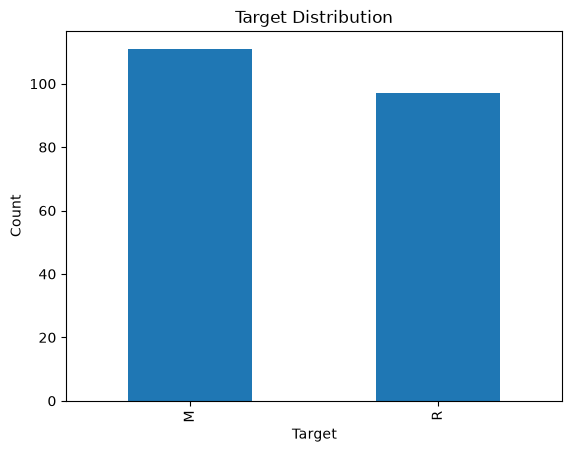

In [44]:
df['target'].value_counts().plot(kind='bar', title='Target Distribution', xlabel='Target', ylabel='Count')

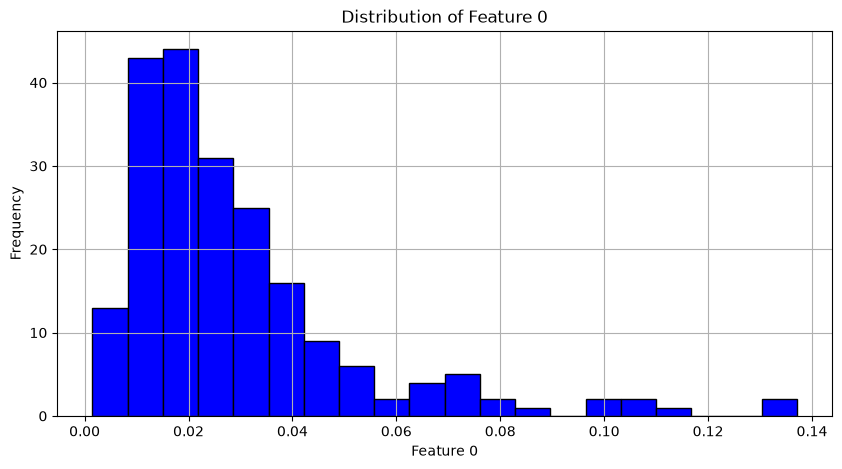

In [47]:
df.iloc[:, 0].hist(bins=20, figsize=(10, 5), color='blue', edgecolor='black')
plt.title('Distribution of Feature 0')
plt.xlabel('Feature 0')
plt.ylabel('Frequency') 
plt.show()

In [48]:
rock = df[df["target"] == "R"]
mine = df[df["target"] == "M"]

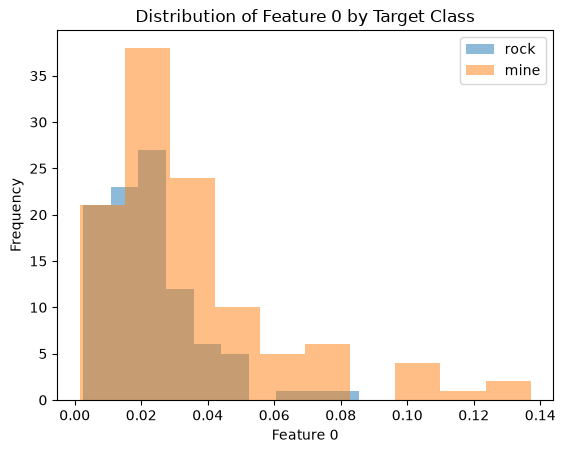

In [49]:
plt.hist(
    rock.iloc[:,0],
    alpha= 0.5,
    label="rock"

)
plt.hist(
    mine.iloc[:,0],
    alpha= 0.5,
    label="mine"
)
plt.title("Distribution of Feature 0 by Target Class")
plt.xlabel("Feature 0")
plt.ylabel("Frequency")
plt.title("Distribution of Feature 0 by Target Class")
plt.legend()

In [51]:
feature_df=df.drop("target", axis=1)
correlation_matrix = feature_df.corr()

In [52]:
correlation_matrix

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute51,Attribute52,Attribute53,Attribute54,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60
Attribute1,1.000000,0.735896,0.571537,0.491438,0.344797,0.238921,0.260815,0.355523,0.353420,0.318276,...,0.254450,0.355299,0.311729,0.322299,0.312067,0.220642,0.313725,0.368132,0.357116,0.347078
Attribute2,0.735896,1.000000,0.779916,0.606684,0.419669,0.332329,0.279040,0.334615,0.316733,0.270782,...,0.320538,0.434548,0.346076,0.383960,0.380165,0.262263,0.280341,0.353042,0.352200,0.358761
Attribute3,0.571537,0.779916,1.000000,0.781786,0.546141,0.346275,0.190434,0.237884,0.252691,0.219637,...,0.238110,0.394076,0.332914,0.367186,0.289731,0.287661,0.380819,0.334108,0.425047,0.373948
Attribute4,0.491438,0.606684,0.781786,1.000000,0.726943,0.352805,0.246440,0.246742,0.247078,0.237769,...,0.174676,0.374651,0.364772,0.334211,0.284955,0.280938,0.340254,0.344865,0.420266,0.400626
Attribute5,0.344797,0.419669,0.546141,0.726943,1.000000,0.597053,0.335422,0.204006,0.177906,0.183219,...,0.115936,0.266617,0.314985,0.205306,0.196472,0.199323,0.219395,0.238793,0.290982,0.253710
Attribute6,0.238921,0.332329,0.346275,0.352805,0.597053,1.000000,0.702889,0.471683,0.327578,0.288621,...,0.171767,0.252288,0.162404,0.164073,0.133464,0.166758,0.161333,0.203986,0.220573,0.178158
Attribute7,0.260815,0.279040,0.190434,0.246440,0.335422,0.702889,1.000000,0.675774,0.470580,0.425448,...,0.184152,0.144051,0.046403,0.163074,0.195541,0.174143,0.186324,0.242646,0.183578,0.222493
Attribute8,0.355523,0.334615,0.237884,0.246742,0.204006,0.471683,0.675774,1.000000,0.778577,0.652525,...,0.260692,0.219038,0.102447,0.234008,0.239551,0.276819,0.267212,0.287603,0.194400,0.146216
Attribute9,0.353420,0.316733,0.252691,0.247078,0.177906,0.327578,0.470580,0.778577,1.000000,0.877131,...,0.174873,0.207996,0.105352,0.202615,0.179342,0.232764,0.193963,0.231745,0.097293,0.095243
Attribute10,0.318276,0.270782,0.219637,0.237769,0.183219,0.288621,0.425448,0.652525,0.877131,1.000000,...,0.167096,0.165537,0.097544,0.146725,0.175254,0.151889,0.140327,0.212277,0.058273,0.097358


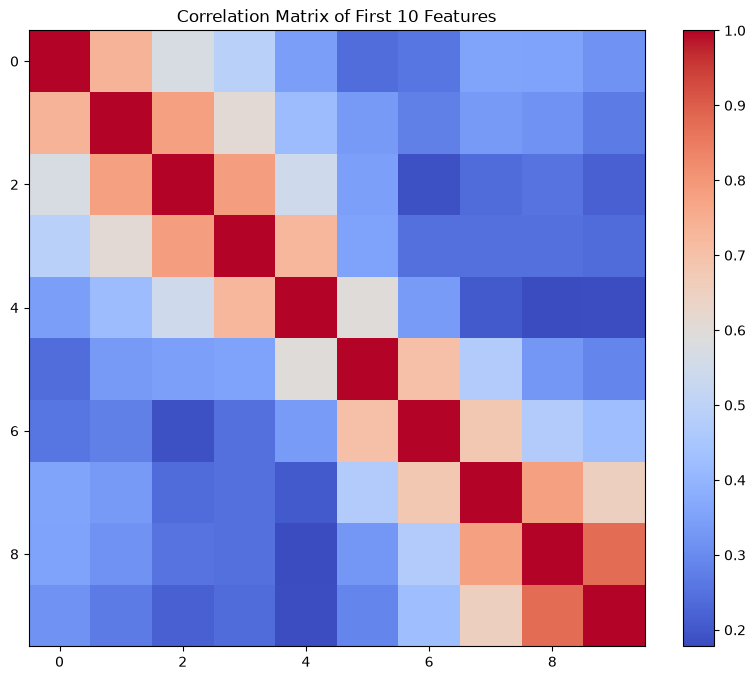

In [53]:
subset = feature_df.iloc[:, :10]
correlation_matrix_subset = subset.corr()
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix_subset, cmap='coolwarm', interpolation='none')  
plt.colorbar()  
plt.title('Correlation Matrix of First 10 Features')
plt.show()


In [56]:
class_mean =   df.groupby("target").mean()
class_mean

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute51,Attribute52,Attribute53,Attribute54,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60
target,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,...,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024


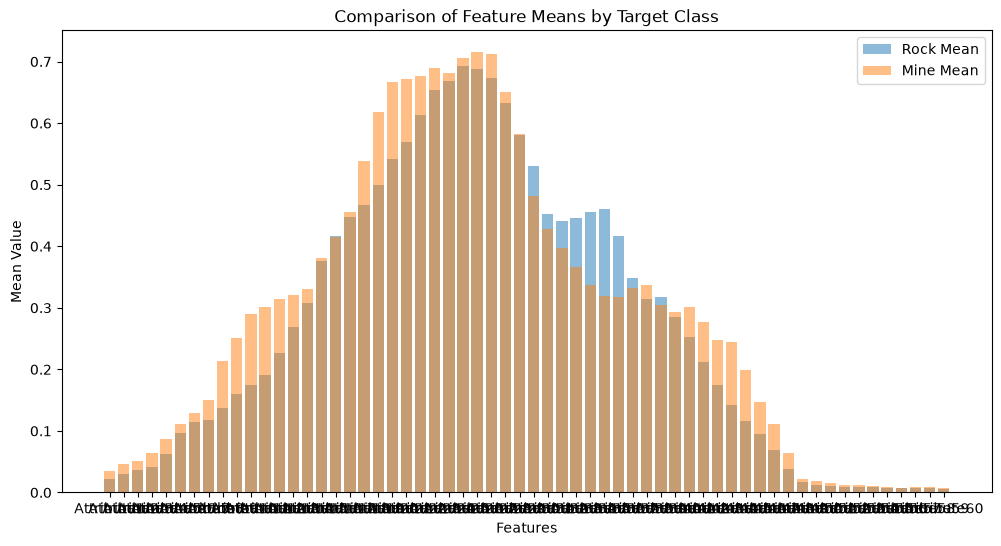

In [57]:
rock_mean = class_mean.loc["R"]
mine_mean = class_mean.loc["M"]

plt.figure(figsize=(12, 6))
plt.bar(rock_mean.index, rock_mean.values, alpha=0.5, label='Rock Mean')
plt.bar(mine_mean.index, mine_mean.values, alpha=0.5, label='Mine Mean')
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.title('Comparison of Feature Means by Target Class')
plt.legend()
plt.show()

In [58]:
X = df.drop("target", axis=1)
y = df["target"]

In [59]:
print(X.shape)
print(y.shape)

(208, 60)
(208,)


In [60]:
from sklearn.model_selection import train_test_split

In [61]:
x_tain,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [62]:
print(x_tain.shape, x_test.shape, y_train.shape, y_test.shape)

(166, 60) (42, 60) (166,) (42,)


In [63]:
random_state=42

In [64]:
print("Original:")
print(y.value_counts(normalize=True))

print("\nTraining:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Original:
target
M    0.533654
R    0.466346
Name: proportion, dtype: float64

Training:
target
M    0.512048
R    0.487952
Name: proportion, dtype: float64

Testing:
target
M    0.619048
R    0.380952
Name: proportion, dtype: float64


In [65]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (166, 60)
X_test : (42, 60)
y_train: (166,)
y_test : (42,)


In [66]:
print("\nOriginal:")
print(y.value_counts(normalize=True))

print("\nTraining:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))


Original:
target
M    0.533654
R    0.466346
Name: proportion, dtype: float64

Training:
target
M    0.536145
R    0.463855
Name: proportion, dtype: float64

Testing:
target
M    0.52381
R    0.47619
Name: proportion, dtype: float64


In [67]:
from sklearn.dummy import DummyClassifier

In [68]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.54,0.46]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[object](2,)","['M','R']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](60,)","['Attribute1','Attribute2','Attribute3',...,'Attribute58','Attribute59', 'Attribute60']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,60
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [69]:
baseline_accuracy = baseline.score(X_test, y_test)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.5238095238095238


In [70]:
baseline_predictions = baseline.predict(X_test)

print(baseline_predictions)

['M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M']


In [71]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": baseline_predictions
})

comparison.head(10)

,Actual,Predicted
0,R,M
1,R,M
2,R,M
3,M,M
4,M,M
5,M,M
6,M,M
7,R,M
8,M,M
9,M,M


In [72]:
y_train.value_counts()

target
M    89
R    77
Name: count, dtype: int64

In [73]:
y_train.value_counts(normalize=True)

target
M    0.536145
R    0.463855
Name: proportion, dtype: float64

In [74]:
y_train.value_counts()

target
M    89
R    77
Name: count, dtype: int64

In [75]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

baseline_accuracy = baseline.score(X_test, y_test)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.5238095238095238


In [76]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": baseline_predictions
})

comparison.head(10)

,Actual,Predicted
0,R,M
1,R,M
2,R,M
3,M,M
4,M,M
5,M,M
6,M,M
7,R,M
8,M,M
9,M,M


In [77]:
from sklearn.preprocessing import StandardScaler

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [79]:
X_train_scaled = scaler.fit_transform(X_train)

In [80]:
scaler.fit_transform(X_train)

array([[ 0.92218084, -0.30070762,  0.49511043, ...,  0.90499423,
         3.89270746,  7.35657804],
       [ 3.10507892,  1.45635601,  0.60959179, ...,  1.80963112,
         2.0031288 , -0.44343477],
       [ 0.20827707, -0.36878573, -0.10514317, ..., -0.84495908,
        -1.1719829 , -0.63941499],
       ...,
       [ 2.59253262,  0.26660997, -0.15464862, ...,  0.34144995,
        -0.67635571, -0.52182685],
       [-0.26765878, -0.06729695, -1.24376855, ..., -0.60767727,
        -0.58342561, -0.65901301],
       [-0.33630337, -0.50818377, -0.49190451, ..., -0.81529885,
        -1.1100295 , -0.9137873 ]], shape=(166, 60))

In [81]:
X_test_scaled = scaler.transform(X_test)

In [82]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(166, 60)
(42, 60)


In [83]:
print("Original:")
print(X_train.iloc[:5, 0].values)

print("\nScaled:")
print(X_train_scaled[:5, 0])

Original:
[0.0491 0.0968 0.0335 0.0132 0.0116]

Scaled:
[ 0.92218084  3.10507892  0.20827707 -0.7207131  -0.793934  ]


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

print("Scaled train mean:", X_train_scaled.mean())
print("Scaled train std:", X_train_scaled.std())

Training shape: (166, 60)
Testing shape: (42, 60)
Scaled train mean: -1.203856291762218e-17
Scaled train std: 1.0


In [85]:
from sklearn.linear_model import LogisticRegression

In [86]:
log_model = LogisticRegression()

In [87]:
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [88]:
y_pred = log_model.predict(X_test_scaled)

In [89]:
print(y_pred)

['R' 'R' 'R' 'M' 'M' 'M' 'M' 'R' 'M' 'R' 'R' 'M' 'R' 'R' 'M' 'R' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'R' 'R' 'M' 'M' 'M' 'R' 'R' 'M' 'R' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'R']


In [90]:
print(y_test.values)

<ArrowStringArray>
['R', 'R', 'R', 'M', 'M', 'M', 'M', 'R', 'M', 'M', 'R', 'M', 'R', 'R', 'R',
 'R', 'M', 'M', 'R', 'M', 'M', 'R', 'M', 'R', 'R', 'R', 'R', 'M', 'M', 'R',
 'R', 'M', 'R', 'M', 'R', 'M', 'M', 'M', 'M', 'M', 'M', 'R']
Length: 42, dtype: str


In [91]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,R,R
1,R,R
2,R,R
3,M,M
4,M,M
5,M,M
6,M,M
7,R,R
8,M,M
9,M,R


In [92]:
from sklearn.metrics import accuracy_score

In [93]:
log_accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.8333333333333334


In [94]:
print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")

Baseline Accuracy: 52.38%
Logistic Regression Accuracy: 83.33%


In [95]:
train_pred = log_model.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, train_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {log_accuracy * 100:.2f}%")

Training Accuracy: 92.17%
Testing Accuracy: 83.33%


In [96]:
probabilities = log_model.predict_proba(X_test_scaled)

print(probabilities[:5])

[[0.01979049 0.98020951]
 [0.33179701 0.66820299]
 [0.45115435 0.54884565]
 [0.55237656 0.44762344]
 [0.64836935 0.35163065]]


In [97]:
print(log_model.classes_)

['M' 'R']


In [98]:
from sklearn.neighbors import KNeighborsClassifier

In [99]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [101]:
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['M','R']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [102]:
knn_pred = knn_model.predict(X_test_scaled)

In [103]:
print(knn_pred)

['R' 'R' 'M' 'M' 'M' 'M' 'M' 'R' 'M' 'R' 'R' 'M' 'M' 'R' 'M' 'R' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'R' 'R' 'R' 'M' 'M' 'M' 'R' 'M' 'R' 'R' 'M' 'M' 'M'
 'M' 'M' 'R' 'M' 'M' 'R']


In [104]:
from sklearn.metrics import accuracy_score

knn_test_accuracy = accuracy_score(y_test, knn_pred)

print(f"KNN Test Accuracy: {knn_test_accuracy * 100:.2f}%")

KNN Test Accuracy: 73.81%


In [105]:
knn_train_pred = knn_model.predict(X_train_scaled)

knn_train_accuracy = accuracy_score(
    y_train,
    knn_train_pred
)

print(f"KNN Training Accuracy: {knn_train_accuracy * 100:.2f}%")
print(f"KNN Testing Accuracy: {knn_test_accuracy * 100:.2f}%")

KNN Training Accuracy: 91.57%
KNN Testing Accuracy: 73.81%


In [107]:
print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")
print(f"KNN Accuracy: {knn_test_accuracy * 100:.2f}%")
print(f"KNN Training Accuracy: {knn_train_accuracy * 100:.2f}%")

Baseline Accuracy: 52.38%
Logistic Regression Accuracy: 83.33%
KNN Accuracy: 73.81%
KNN Training Accuracy: 91.57%


In [108]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_train_pred = knn_model.predict(X_train_scaled)

knn_train_accuracy = accuracy_score(
    y_train,
    knn_train_pred
)

knn_test_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print(f"KNN Training Accuracy: {knn_train_accuracy * 100:.2f}%")
print(f"KNN Testing Accuracy: {knn_test_accuracy * 100:.2f}%")

KNN Training Accuracy: 91.57%
KNN Testing Accuracy: 73.81%


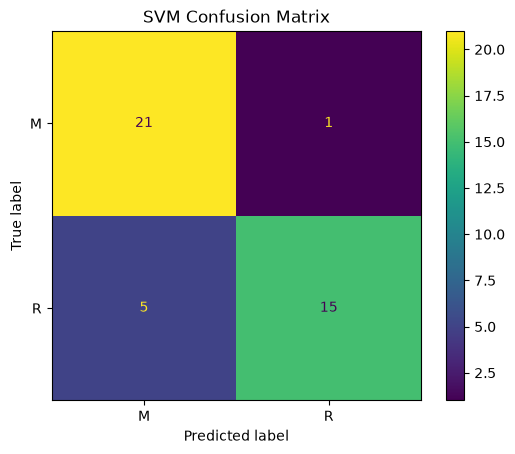

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [111]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           M       0.81      0.95      0.88        22
           R       0.94      0.75      0.83        20

    accuracy                           0.86        42
   macro avg       0.87      0.85      0.85        42
weighted avg       0.87      0.86      0.86        42



In [113]:
from sklearn.metrics import accuracy_score

svm_test_accuracy = accuracy_score(y_test, svm_pred)

model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "KNN",
        "SVM"
    ],
    "Test Accuracy": [
        baseline_accuracy,
        log_accuracy,
        knn_test_accuracy,
        svm_test_accuracy
    ]
})

model_results

model_results

,Model,Test Accuracy
0,Baseline,0.523810
1,Logistic Regression,0.833333
2,KNN,0.738095
3,SVM,0.857143


In [115]:
from sklearn.model_selection import cross_val_score

log_cv = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:", log_cv)
print("Mean CV Accuracy:", log_cv.mean())
print("CV Standard Deviation:", log_cv.std())

print("Logistic Regression CV Scores:", log_cv)
print("Mean CV Accuracy:", log_cv.mean())
print("CV Standard Deviation:", log_cv.std())

Logistic Regression CV Scores: [0.76470588 0.72727273 0.72727273 0.78787879 0.81818182]
Mean CV Accuracy: 0.7650623885918003
CV Standard Deviation: 0.03520939073119826
Logistic Regression CV Scores: [0.76470588 0.72727273 0.72727273 0.78787879 0.81818182]
Mean CV Accuracy: 0.7650623885918003
CV Standard Deviation: 0.03520939073119826


In [116]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Create pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(probability=True))
])

# Hyperparameters to test
param_grid = {
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__gamma": ["scale", "auto", 0.01, 0.1],
    "classifier__kernel": ["rbf"]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train only using training data
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}

Best Cross Validation Accuracy:
0.8675579322638146


C:\Users\naman yadav\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
